In [8]:
import numpy as np
import bilby
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from astropy.cosmology import Planck18, z_at_value
import astropy.units as u
from nmma.core.conversion import luminosity_distance_to_redshift
from bilby.gw.conversion import component_masses_to_chirp_mass
import scipy.interpolate as interpolate
import scipy.stats as stats

events = pd.read_csv("./events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

source = 80
posterior = np.load(f"./gw_posteriors/source_{source}/posterior.npz")
posterior_mm = np.load(f"./gw_posteriors/source_{source}/posterior_mm.npz")

In [9]:
prior_redshift = bilby.gw.prior.UniformSourceFrame(minimum=0.0089661508, maximum=1.1421225, name="redshift")

In [13]:
def mass_source_frame_samples(prior, mm=False):
    samples = prior.sample(1_000_000)

    m1, m2 = bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses(samples["chirp_mass"], samples["mass_ratio"])
    if not mm:
        redshift = luminosity_distance_to_redshift(samples["luminosity_distance"])
    else:
        redshift = np.random.normal(loc=events.loc[source, "redshift"], scale=0.01 * events.loc[source, "redshift"], size=1_000_000)
    
    return m1  / (1+redshift), m2  / (1+redshift)


In [14]:
MCHIRP = events.loc[source, "chirp_mass"]
prior = bilby.gw.prior.PriorDict("./gw_posteriors/bns.prior")
prior["chirp_mass"] = bilby.gw.prior.UniformInComponentsChirpMass(MCHIRP-0.01, MCHIRP+0.01)
del prior["chi_1"]
del prior["chi_2"]
del prior["lambda_1"]
del prior["lambda_2"]
del prior["psi"]
del prior["phase"]
del prior["theta_jn"]

In [15]:
m1, m2 = mass_source_frame_samples(prior)
m1_mm, m2_mm = mass_source_frame_samples(prior, mm=True)

## GW only

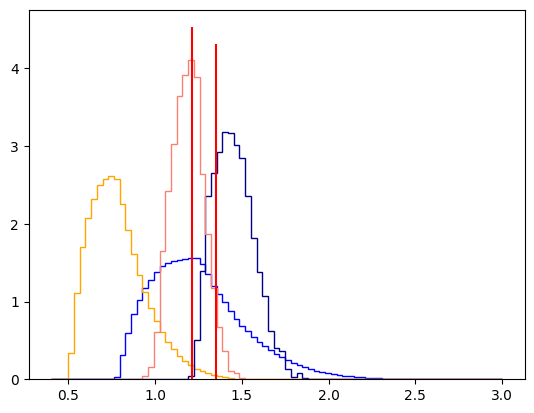

In [560]:

plt.hist(m1, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2, density=True, histtype="step", color="orange", bins=bins)

plt.hist(posterior["mass_1_source"], histtype="step", color="darkblue", bins=bins, density=True)
plt.hist(posterior["mass_2_source"], histtype="step", color="salmon", bins=bins, density=True)


plt.vlines([events.loc[source, "mass_1_source"]], *plt.gca().get_ylim(), color="red")
plt.vlines([events.loc[source, "mass_2_source"]], *plt.gca().get_ylim(), color="red")

plt.show()


In [16]:
def generate_fake_prior(chirp_mass_detector):

    def fake_prior(m1, m2):
        q = m2/m1
        chirp_mass_source = (m1*m2)**0.6 / (m1+m2)**0.2

        zmin = (chirp_mass_detector - 0.01) / chirp_mass_source -1 
        zmax = (chirp_mass_detector + 0.01) / chirp_mass_source - 1

        z_arr = np.linspace(zmin, zmax, 100)
        y_arr = (1+z_arr)**2 * np.exp(prior_redshift.ln_prob(z_arr))

        constraints = 0.4 <= q <= 1.
        constraints &= zmin < zmax


        return np.where(constraints, np.trapezoid(x=z_arr, y=y_arr), 0)


    return fake_prior

fake_prior = generate_fake_prior(events.loc[source, "chirp_mass"])

In [17]:
nbins = 80
bins = np.linspace(0.4, 3, nbins)
hist, xedges, yedges = np.histogram2d(m1, m2, bins=bins, density=True)
xedges = 0.5 * (xedges[:-1] + xedges[1:])
yedges = 0.5 * (yedges[:-1] + yedges[1:])

bilby_prior = interpolate.RegularGridInterpolator(points=(xedges, yedges), values=hist)

In [18]:
bilby_prior((events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"])) / fake_prior(events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"])

np.float64(31.011853834355577)

In [19]:
factors = np.zeros(1000)

for j in range(1000):
    factors[j] = bilby_prior((posterior["mass_1_source"][j], posterior["mass_2_source"][j])) / fake_prior(posterior["mass_1_source"][j], posterior["mass_2_source"][j])

In [20]:
factors_prior = np.zeros(1000)

for j in range(1000):
    factors_prior[j] = bilby_prior((m1[j], m2[j])) / fake_prior(m1[j], m2[j])

(15.0, 40.0)

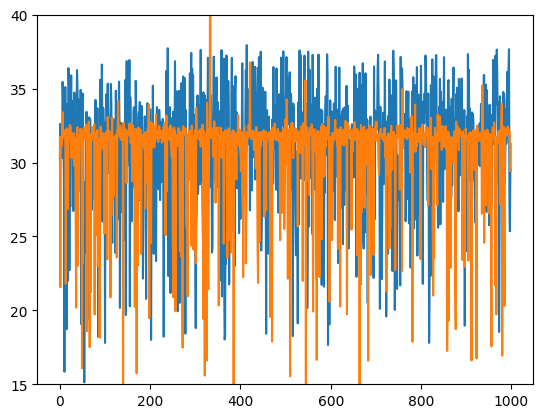

In [21]:
plt.plot(factors)
plt.plot(factors_prior)
plt.ylim((15, 40))

/tmp/ipykernel_1188501/4206147544.py:7: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xedges, yedges, hist, colors="blue", levels=5, label="bilby", linestyles="solid")
/tmp/ipykernel_1188501/4206147544.py:8: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xedges, yedges, hist_fake*32, colors="green", levels=5, label="formula", linestyles="solid")


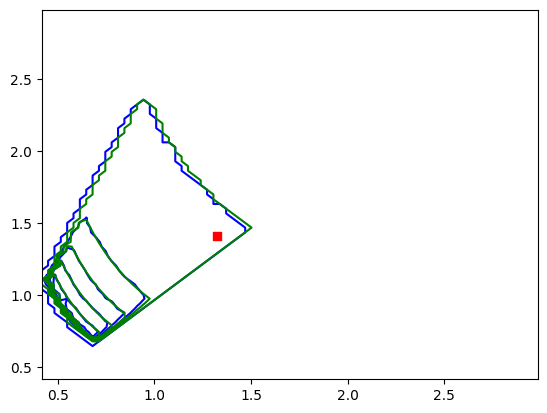

In [42]:
hist_fake = np.zeros((nbins-1, nbins-1))

for j in range(nbins-1):
    for k in range(nbins-1):
        hist_fake[j, k] = fake_prior(xedges[j], yedges[k])

plt.contour(xedges, yedges, hist, colors="blue", levels=5, label="bilby", linestyles="solid")
plt.contour(xedges, yedges, hist_fake*32, colors="green", levels=5, label="formula", linestyles="solid")
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")

/tmp/ipykernel_1188501/2932300418.py:7: RuntimeWarning: divide by zero encountered in log
  plt.contourf(xedges, yedges, np.log(hist_fake))


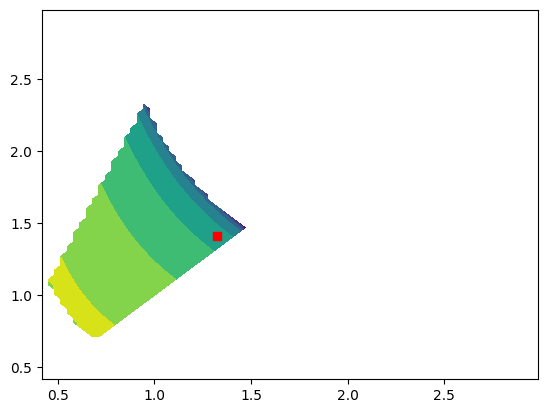

In [23]:
hist_fake = np.zeros((nbins-1, nbins-1))

for j in range(nbins-1):
    for k in range(nbins-1):
        hist_fake[j, k] = fake_prior(xedges[j], yedges[k])
    
plt.contourf(xedges, yedges, np.log(hist_fake))
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")

/tmp/ipykernel_206253/2991835193.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio = hist / hist_fake
/tmp/ipykernel_206253/2991835193.py:1: RuntimeWarning: invalid value encountered in divide
  ratio = hist / hist_fake
/tmp/ipykernel_206253/2991835193.py:7: RuntimeWarning: divide by zero encountered in log
  plt.contourf(xedges, yedges, np.log(ratio))


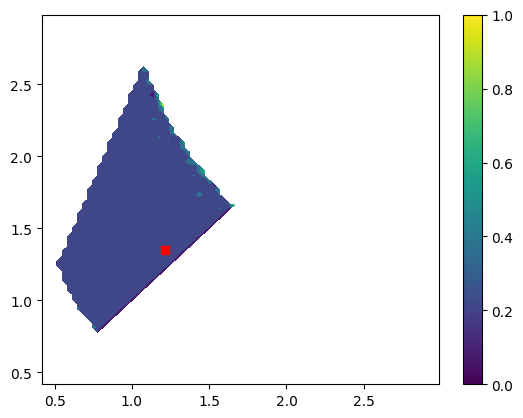

In [598]:
ratio = hist / hist_fake

ratio[np.isnan(ratio)] = 0.
ratio[np.isinf(ratio)] = 0


plt.contourf(xedges, yedges, np.log(ratio))
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")
plt.colorbar()

## MM

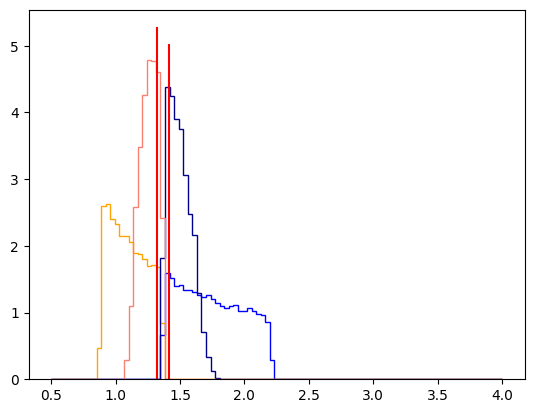

In [34]:
bins = np.linspace(0.5, 4, 100)

plt.hist(m1_mm, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2_mm, density=True, histtype="step", color="orange", bins=bins)

plt.hist(posterior_mm["mass_1_source"], histtype="step", color="darkblue", bins=bins, density=True)
plt.hist(posterior_mm["mass_2_source"], histtype="step", color="salmon", bins=bins, density=True)


plt.vlines([events.loc[source, "mass_1_source"]], *plt.gca().get_ylim(), color="red")
plt.vlines([events.loc[source, "mass_2_source"]], *plt.gca().get_ylim(), color="red")


In [666]:
np.mean(posterior_mm["mass_1"] / posterior_mm["mass_1_source"] - 1)

np.float64(0.30644929445053365)

In [667]:
events.loc[source, "redshift"]

np.float64(0.3072860394549018)

In [ ]:
def generate_fake_prior(chirp_mass_detector):

    def fake_prior(m1, m2):
        q = m2/m1
        chirp_mass_source = (m1*m2)**0.6 / (m1+m2)**0.2

        zmin = (chirp_mass_detector - 0.01) / chirp_mass_source -1
        zmax = (chirp_mass_detector + 0.01) / chirp_mass_source - 1

        z_arr = np.linspace(zmin, zmax, 100)
        y_arr = (1+z_arr)**2 * stats.norm.pdf(z_arr, loc=events.loc[source, "redshift"], scale=0.01 * events.loc[source, "redshift"])

        constraints = 0.4 <= q <= 1.
        constraints &= zmin < zmax


        return np.where(constraints, np.trapezoid(x=z_arr, y=y_arr), 0)


    return fake_prior

fake_prior = generate_fake_prior(events.loc[source, "chirp_mass"])

In [648]:
nbins = 1000
bins = np.linspace(0.4, 3, nbins)
hist, xedges, yedges = np.histogram2d(m1_mm, m2_mm, bins=bins, density=True)
xedges = 0.5 * (xedges[:-1] + xedges[1:])
yedges = 0.5 * (yedges[:-1] + yedges[1:])

bilby_prior = interpolate.RegularGridInterpolator(points=(xedges, yedges), values=hist)

In [649]:
bilby_prior((events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"]))

array(48.08837412)

In [650]:
fake_prior(events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"])

array(1.70305181)

In [651]:
factors = np.zeros(1000)

for j in range(1000):
    factors[j] = bilby_prior((posterior_mm["mass_1_source"][j], posterior_mm["mass_2_source"][j])) / fake_prior(posterior_mm["mass_1_source"][j], posterior_mm["mass_2_source"][j])

In [652]:
factors_prior = np.zeros(1000)

for j in range(1000):
    factors_prior[j] = bilby_prior((m1_mm[j], m2_mm[j])) / fake_prior(m1_mm[j], m2_mm[j])

(20.0, 30.0)

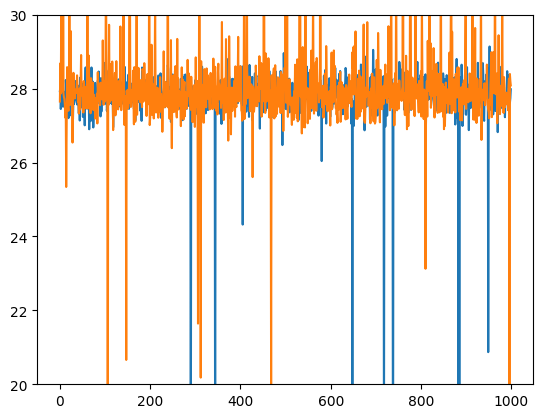

In [653]:
plt.plot(factors)
plt.plot(factors_prior)
plt.ylim((20, 30))

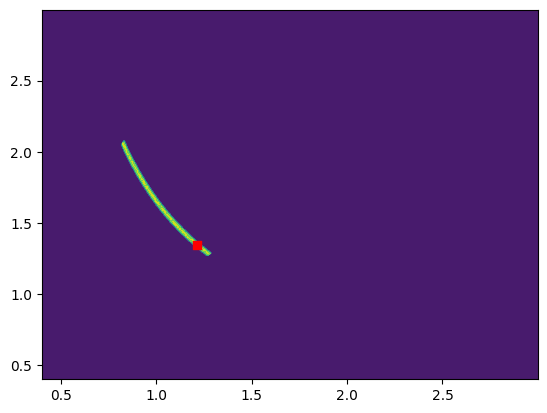

In [657]:
plt.contourf(xedges, yedges, (hist))
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")

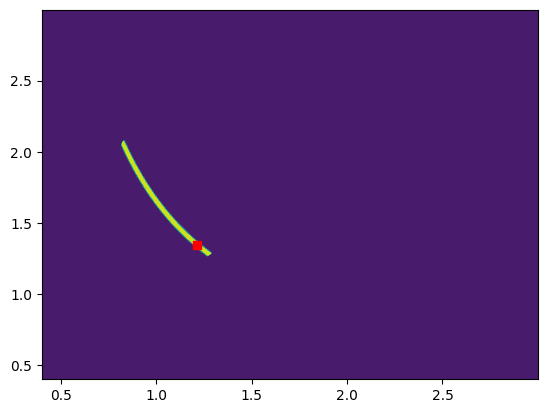

In [658]:
hist_fake = np.zeros((nbins-1, nbins-1))

for j in range(nbins-1):
    for k in range(nbins-1):
        hist_fake[j, k] = fake_prior(xedges[j], yedges[k])
    
plt.contourf(xedges, yedges, (hist_fake))
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")

/tmp/ipykernel_206253/2991835193.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio = hist / hist_fake
/tmp/ipykernel_206253/2991835193.py:1: RuntimeWarning: invalid value encountered in divide
  ratio = hist / hist_fake
/tmp/ipykernel_206253/2991835193.py:7: RuntimeWarning: divide by zero encountered in log
  plt.contourf(xedges, yedges, np.log(ratio))


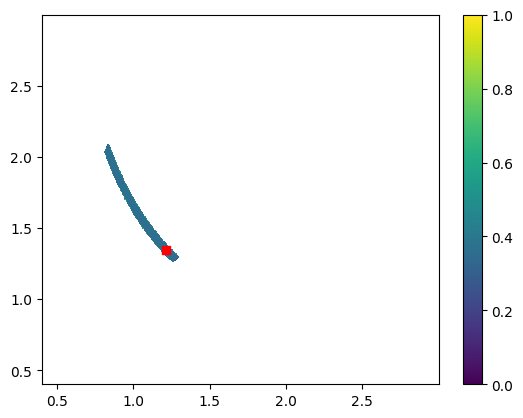

In [660]:
ratio = hist / hist_fake

ratio[np.isnan(ratio)] = 0.
ratio[np.isinf(ratio)] = 0


plt.contourf(xedges, yedges, np.log(ratio))
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")
plt.colorbar()